<a href="https://colab.research.google.com/github/Ronak352/AI-Powered-Customer-Churn-Prediction-Analytics-System/blob/main/AI_Powered_Customer_Churn_Prediction_%26_Analytics_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Churn_Modelling.csv")

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.drop(["RowNumber","CustomerId","Surname"],axis=1, inplace=True)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 11)

In [ ]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


**EDA-Exploratry Data Analysis**


Statistical Summary


In [ ]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Checking for missing values

In [ ]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


Checking the distribution of target variable

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


Univarient Analysis

1.Age Distribution

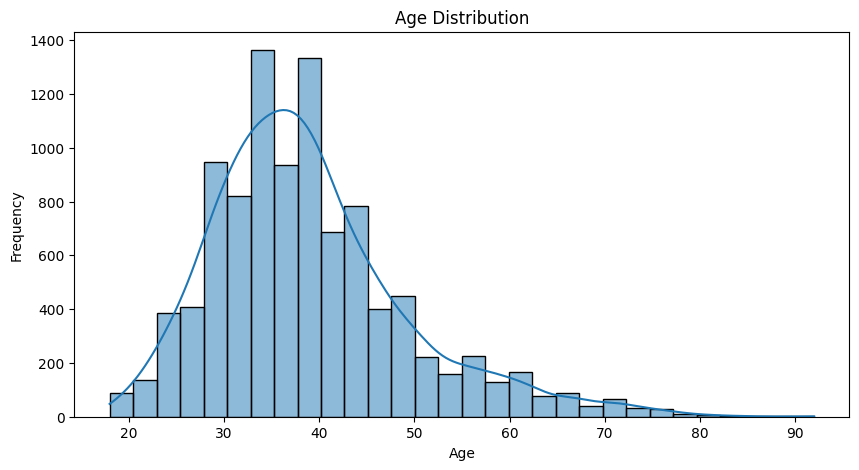

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Age"],bins=30,kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

2. Balance Distribution


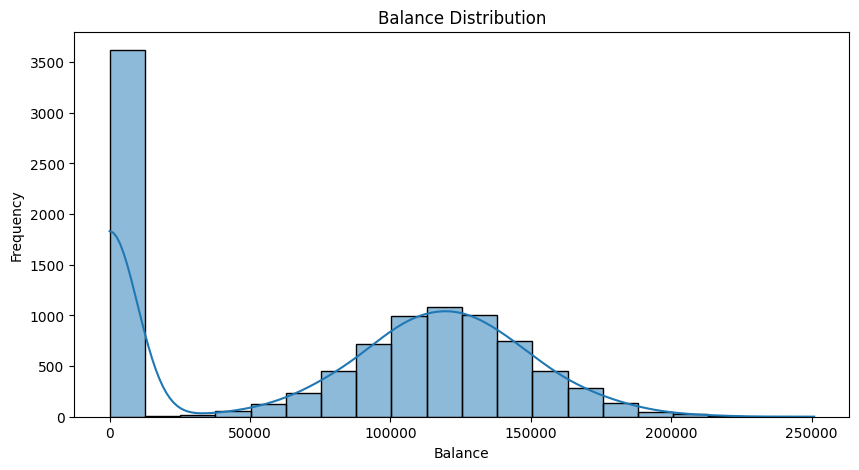

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Balance"],kde=True,bins=20)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

3. Credit Score Distribution

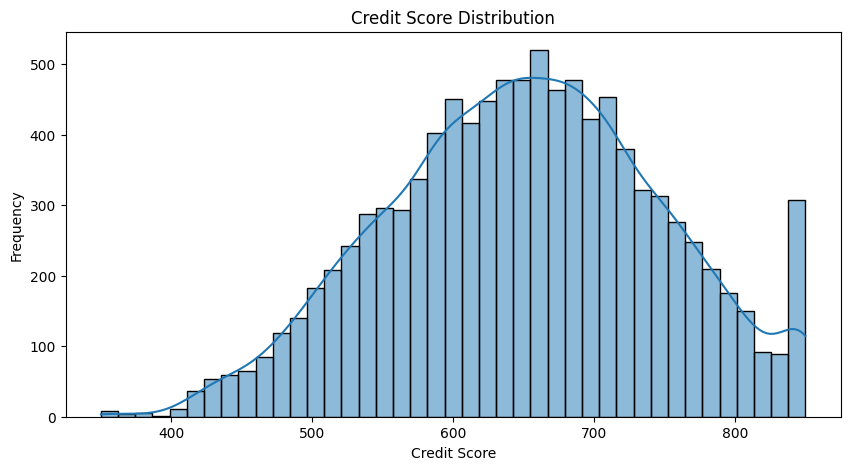

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['CreditScore'],kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

Analysis of Categorial Features

1. geographical analysis

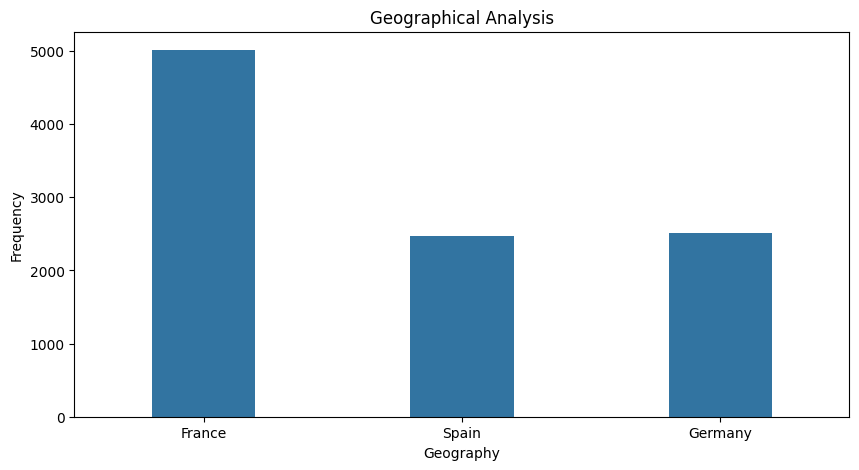

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x="Geography",data=df,width=0.4)

plt.title("Geographical Analysis")
plt.xlabel("Geography")
plt.ylabel("Frequency")
plt.show()

2. Gender Distribution

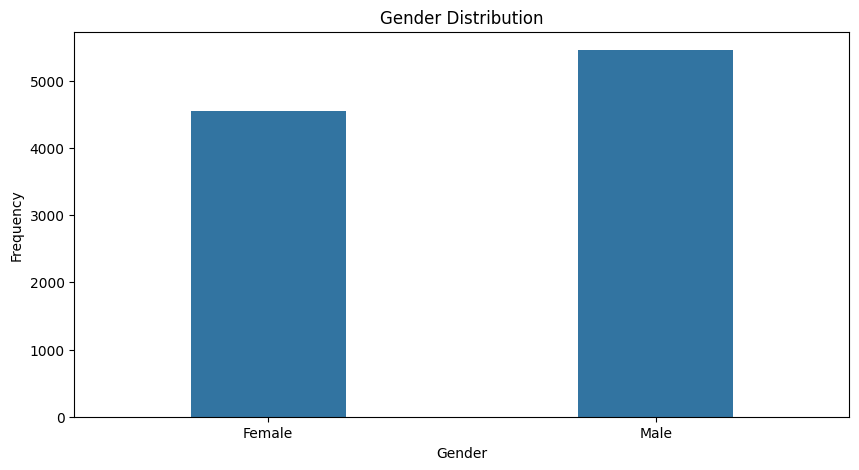

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x="Gender",data=df,width=0.4)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()


Bivarient Analysis

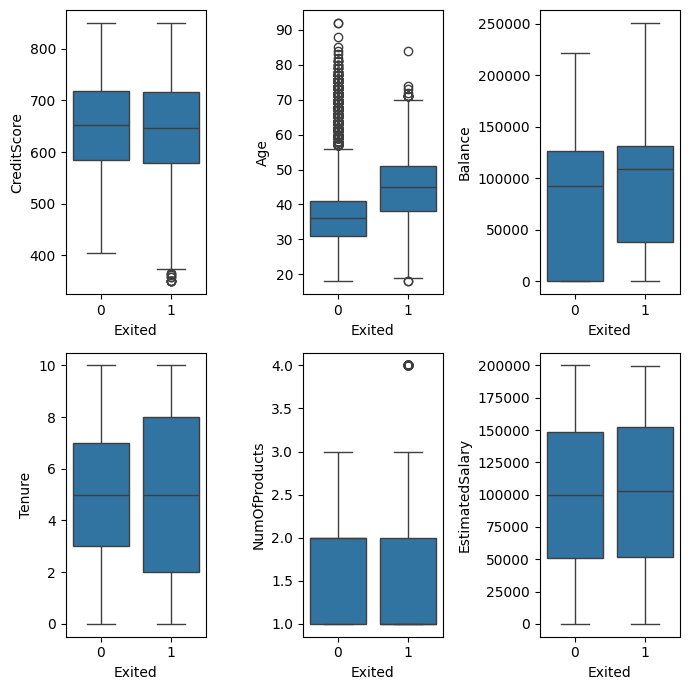

In [ ]:
fig,axrr=plt.subplots(2,3,figsize=(7,7))
sns.boxplot(x ="Exited",y="CreditScore",data=df,ax=axrr[0][0])
sns.boxplot(x ="Exited",y="Age",data=df,ax=axrr[0][1])
sns.boxplot(x ="Exited",y="Balance",data=df,ax=axrr[0][2])
sns.boxplot(x ="Exited",y="Tenure",data=df,ax=axrr[1][0])
sns.boxplot(x ="Exited",y="NumOfProducts",data=df,ax=axrr[1][1])
sns.boxplot(x ="Exited",y="EstimatedSalary",data=df,ax=axrr[1][2])

plt.tight_layout()
#  It is a function in Python's Matplotlib library that automatically adjusts subplot parameters.
#  so that your plots fit neatly within the figure area without overlapping.

plt.show()

# From showing the all the plots in the Age Graph i see that there are the outlier are detected. so we must remove it.

Correlation Analysis

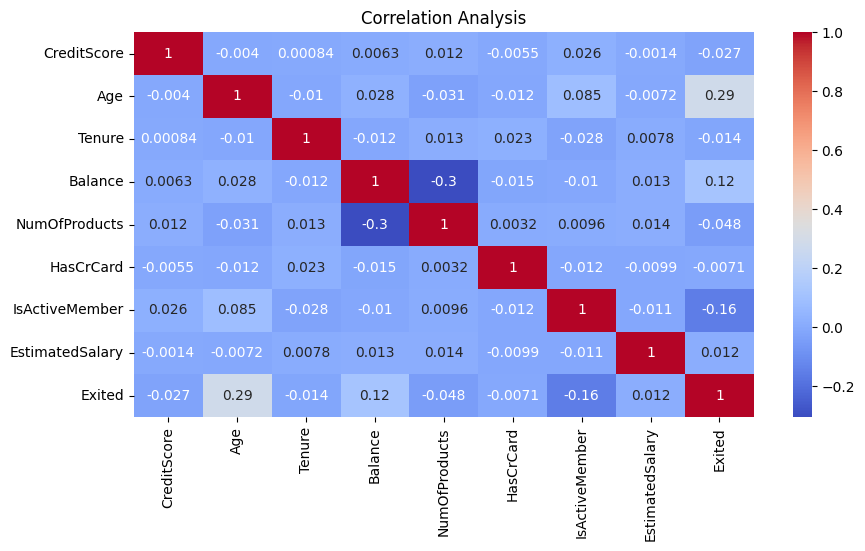

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),
             annot=True,
             cmap="coolwarm",

            )

# the cmap parameter stands for colormap. It controls the colors used to represent the values in the heatmap.
# Here:  Negative correlations → Blue ,   Zero correlation → White , Positive correlations → Red

plt.title("Correlation Analysis")
plt.show()

# It shows that the correlation is not much powerful from the showing the columns.
#If it was found correlation in our data then we must drop the column.

**Feature Engineering **

Feature Engineering is the process of creating, transforming, selecting, or extracting features (input variables) from raw data to improve the performance of a machine learning model.


1.Balance to Salary ratio

In [ ]:
df["Balance_to_Salary"]=df["Balance"]/df["EstimatedSalary"]

2. Tenure by Age


In [ ]:
df["Tenure_by_Age"]=df["Tenure"]/(df["Age"])

In [ ]:
df.shape

(10000, 13)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,Tenure_by_Age
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512


**Feature Encoding**

It is the process where categorial columns are converted into the numerical columns using the
Most Commonly Used Encodings

Encoding Type ,	Use Case

Label Encoding , 	Binary categories (Yes/No, Male/Female)

One-Hot Encoding, Nominal categories (City, Country, Department)

Ordinal Encoding, Ordered categories (Low, Medium, High)

Frequency Encoding, 	High-cardinality features

Target Encoding, 	Advanced predictive modeling




1.Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df["Gender"]


,Gender
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,0
9998,1


2. One-Hot Encoding

In [ ]:
df=pd.get_dummies(df,columns=["Geography"],drop_first=True)
# The drop_first=True parameter is used to remove the first dummy column created during One-Hot Encoding.
# It means if two columns shows the false then remaining columns is true . so we don't need to write it.
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,Tenure_by_Age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512,False,True


**Defining Feature and Target Variables**

In [ ]:
x=df.drop(["Exited"],axis=1)
y=df["Exited"]
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,Tenure_by_Age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512,False,True


**Splitting the Dataset**


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

x_test.shape

(2000, 13)

In [ ]:
x_train.shape

(8000, 13)

**Feature Scaling**

Feature Scaling is a data preprocessing technique used to bring numerical features to a similar scale so that features with larger values do not dominate features with smaller values during model training.




The three main types of Feature Scaling are:

1. Standardization (StandardScaler)- Z score

2. Normalization (MinMaxScaler)

3. Robust Scaling (RobustScaler)

In [ ]:
from sklearn.preprocessing import StandardScaler

SC=StandardScaler()
x_train=SC.fit_transform(x_train)
x_test=SC.transform(x_test)

# fit_transform() is used on the training data to calculate the mean and standard deviation and scale the data.
#  transform() is used on the test data to apply the same scaling parameters learned from the training data.
# This prevents data leakage and ensures consistent feature scaling between training and testing datasets.

# if we used fit_tranform in the test then This would calculate a new mean and standard deviation from the test data,
# causing data leakage and inconsistent scaling.so, we use the tranform only so, tarined mean and standard deviation we can use on it.



**Model Training**

1. Logistic Regression
2. KNN Classifier
3. Naives Bayes
4. Random Forest
5. XGB Classfier
6. ANN


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

**Logistic Regression**

Accuracy: 0.8125
Precision: 0.56
Recall: 0.21374045801526717
F1 Score: 0.30939226519337015


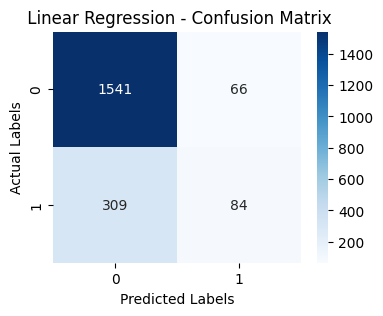

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)

y_pred_lr=lr_model.predict(x_test)

lr_accuracy=accuracy_score(y_test,y_pred_lr)
lr_precision=precision_score(y_test,y_pred_lr)
lr_recall=recall_score(y_test,y_pred_lr)
lr_f1=f1_score(y_test,y_pred_lr)
lr_conf_matrix=confusion_matrix(y_test,y_pred_lr)


plt.figure(figsize=(4,3))
sns.heatmap(lr_conf_matrix,annot=True,fmt="d",cmap="Blues")
plt.title(" Linear Regression - Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")


print("Accuracy:",lr_accuracy)
print("Precision:",lr_precision)
print("Recall:",lr_recall)
print("F1 Score:",lr_f1)

plt.show()






In [ ]:
model_results=[]

model_results.append({"Model":"Logistic Regression",
                       "Accuracy":lr_accuracy,
                       "Precision":lr_precision,
                       "Recall":lr_recall,
                       "F1 Score":lr_f1})

2. KNN Classifier-K Nearest Neighbour Model

IT is distance based classifier.


Accuracy: 0.831
Precision: 0.6170212765957447
Recall: 0.36895674300254455
F1 Score: 0.46178343949044587


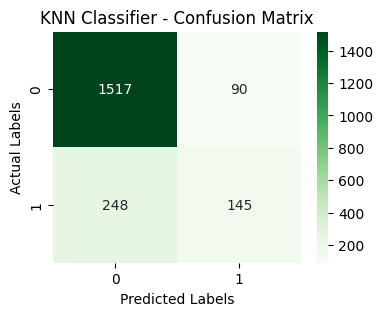

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier()
knn_model.fit(x_train,y_train)

y_pred_knn=knn_model.predict(x_test)

knn_accuracy=accuracy_score(y_test,y_pred_knn)
knn_precision=precision_score(y_test,y_pred_knn)
knn_recall=recall_score(y_test,y_pred_knn)
knn_f1=f1_score(y_test,y_pred_knn)
knn_conf_matrix=confusion_matrix(y_test,y_pred_knn)

plt.figure(figsize=(4,3))
sns.heatmap(knn_conf_matrix,annot=True,fmt="d",cmap="Greens")
plt.title("KNN Classifier - Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")


print("Accuracy:",knn_accuracy)
print("Precision:",knn_precision)
print("Recall:",knn_recall)
print("F1 Score:",knn_f1)

plt.show()



In [ ]:
model_results.append({"Model":"KNN Classifier",
                       "Accuracy":knn_accuracy,
                       "Precision":knn_precision,
                       "Recall":knn_recall,
                       "F1 Score":knn_f1})

In [ ]:
model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8125,
  'Precision': 0.56,
  'Recall': 0.21374045801526717,
  'F1 Score': 0.30939226519337015},
 {'Model': 'KNN Classifier',
  'Accuracy': 0.831,
  'Precision': 0.6170212765957447,
  'Recall': 0.36895674300254455,
  'F1 Score': 0.46178343949044587}]

**3. Naive Bayes**

Naive Bayes is a supervised machine learning classification algorithm based on Bayes' Theorem. It predicts the probability that a data point belongs to a particular class by assuming that all features are independent of each other.


Accuracy: 0.8275
Precision: 0.6967213114754098
Recall: 0.21628498727735368
F1 Score: 0.3300970873786408


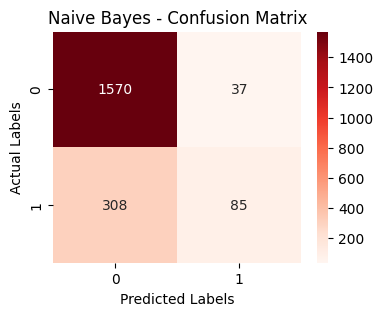

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model=GaussianNB()

nb_model.fit(x_train,y_train)

y_pred_nb=nb_model.predict(x_test)


nb_accuracy=accuracy_score(y_test , y_pred_nb)
nb_precision=precision_score(y_test , y_pred_nb)
nb_recall=recall_score(y_test , y_pred_nb)
nb_f1=f1_score(y_test , y_pred_nb)
nb_conf_matrix=confusion_matrix(y_test , y_pred_nb)

plt.figure(figsize=(4,3))
sns.heatmap(nb_conf_matrix,annot=True,fmt="d",cmap="Reds")
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

print("Accuracy:",nb_accuracy)
print("Precision:",nb_precision)
print("Recall:",nb_recall)
print("F1 Score:",nb_f1)

plt.show()

In [ ]:
model_results.append({"Model":"Naive Bayes",
                       "Accuracy":nb_accuracy,
                       "Precision":nb_precision,
                       "Recall":nb_recall,
                       "F1 Score":nb_f1})

**4. Random Forest**

Random Forest is a supervised machine learning algorithm used for both classification and regression tasks. It is an ensemble learning technique that combines multiple Decision Trees and produces the final prediction based on majority voting (classification) or averaging (regression).

Accuracy: 0.869
Precision: 0.7651821862348178
Recall: 0.48091603053435117
F1 Score: 0.590625


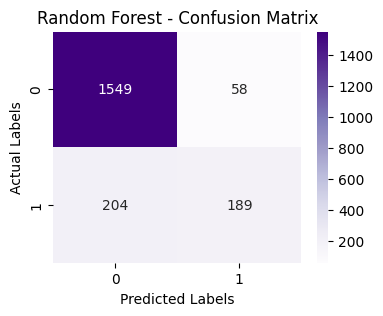

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=100,
    random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

rf_accuracy=accuracy_score(y_test , y_pred_rf)
rf_precision=precision_score(y_test , y_pred_rf)
rf_recall=recall_score(y_test , y_pred_rf)
rf_f1=f1_score(y_test , y_pred_rf)
rf_conf_matrix=confusion_matrix(y_test , y_pred_rf)

plt.figure(figsize=(4,3))
sns.heatmap(rf_conf_matrix,annot=True,fmt="d",cmap="Purples")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

print("Accuracy:",rf_accuracy)
print("Precision:",rf_precision)
print("Recall:",rf_recall)
print("F1 Score:",rf_f1)

plt.show()

In [ ]:
model_results.append({"Model":"Random Forest",
                       "Accuracy":rf_accuracy,
                       "Precision":rf_precision,
                       "Recall":rf_recall,
                       "F1 Score":rf_f1})

**5. XGBoost Classifier**

XGBoost (Extreme Gradient Boosting) is a powerful supervised machine learning algorithm based on the Boosting technique. It builds multiple Decision Trees sequentially, where each new tree tries to correct the errors made by the previous trees.


Accuracy: 0.8635
Precision: 0.7068965517241379
Recall: 0.5216284987277354
F1 Score: 0.6002928257686676


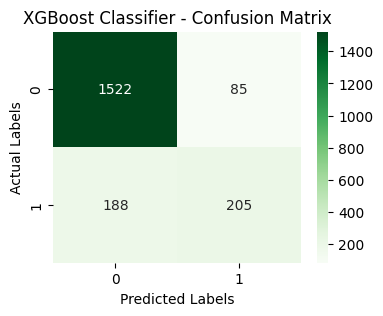

In [ ]:
from xgboost import XGBClassifier

xgb_model=XGBClassifier()

xgb_model.fit(x_train,y_train)

y_pred_xgb=xgb_model.predict(x_test)

xgb_accuracy=accuracy_score(y_test , y_pred_xgb)
xgb_precision=precision_score(y_test , y_pred_xgb)
xgb_recall=recall_score(y_test , y_pred_xgb)
xgb_f1=f1_score(y_test , y_pred_xgb)
xgb_conf_matrix=confusion_matrix(y_test , y_pred_xgb)

plt.figure(figsize=(4,3))
sns.heatmap(xgb_conf_matrix,annot=True,fmt="d",cmap="Greens")
plt.title("XGBoost Classifier - Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

print("Accuracy:",xgb_accuracy)
print("Precision:",xgb_precision)
print("Recall:",xgb_recall)
print("F1 Score:",xgb_f1)

plt.show()

In [ ]:
model_results.append({"Model":"XG Boost Classifier",
                       "Accuracy":xgb_accuracy,
                       "Precision":xgb_precision,
                       "Recall":xgb_recall,
                       "F1 Score":xgb_f1})

**6. ANN-Artificial Neural Network**

Artificial Neural Network (ANN) is a machine learning model inspired by the structure and functioning of the human brain. It consists of interconnected nodes called neurons, organized into layers, which learn patterns from data and make predictions.

In [ ]:
import tensorflow as tf
from tensorflow import keras

ann_model=keras.Sequential([
    keras.layers.Input(shape=(x_train.shape[1],)),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



In [ ]:
history=ann_model.fit(x_train,y_train,epochs=100,batch_size=32, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8027 - loss: 0.4645 - val_accuracy: 0.8263 - val_loss: 0.4186
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8270 - loss: 0.4138 - val_accuracy: 0.8413 - val_loss: 0.3993
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8452 - loss: 0.3843 - val_accuracy: 0.8531 - val_loss: 0.3693
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8573 - loss: 0.3534 - val_accuracy: 0.8487 - val_loss: 0.3534
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8602 - loss: 0.3448 - val_accuracy: 0.8587 - val_loss: 0.3434
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8644 - loss: 0.3366 - val_accuracy: 0.8562 - val_loss: 0.3450
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8628 - loss: 0.3335 - val_accuracy: 0.8600 - val_loss: 0.3422
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8645 - loss: 0.3297 - val_accu

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.833
Precision: 0.5758354755784062
Recall: 0.5699745547073791
F1 Score: 0.5728900255754475


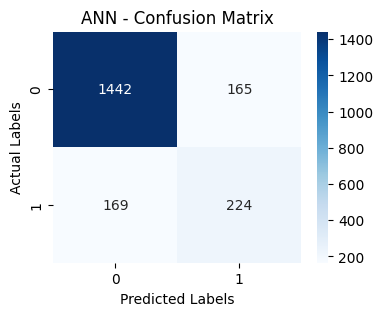

In [ ]:
y_pred_ann=ann_model.predict(x_test)
y_pred_ann=np.where(y_pred_ann>0.5,1,0)

ann_accuracy=accuracy_score(y_test , y_pred_ann)
ann_precision=precision_score(y_test , y_pred_ann)
ann_recall=recall_score(y_test , y_pred_ann)
ann_f1=f1_score(y_test , y_pred_ann)
ann_conf_matrix=confusion_matrix(y_test , y_pred_ann)

plt.figure(figsize=(4,3))
sns.heatmap(ann_conf_matrix,annot=True,fmt="d",cmap="Blues")
plt.title("ANN - Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

print("Accuracy:",ann_accuracy)
print("Precision:",ann_precision)
print("Recall:",ann_recall)
print("F1 Score:",ann_f1)

plt.show()

In [ ]:
model_results.append({"Model":"ANN Model",
                       "Accuracy":ann_accuracy,
                       "Precision":ann_precision,
                       "Recall":ann_recall,
                       "F1 Score":ann_f1})

In [ ]:
model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8125,
  'Precision': 0.56,
  'Recall': 0.21374045801526717,
  'F1 Score': 0.30939226519337015},
 {'Model': 'KNN Classifier',
  'Accuracy': 0.831,
  'Precision': 0.6170212765957447,
  'Recall': 0.36895674300254455,
  'F1 Score': 0.46178343949044587},
 {'Model': 'Naive Bayes',
  'Accuracy': 0.8275,
  'Precision': 0.6967213114754098,
  'Recall': 0.21628498727735368,
  'F1 Score': 0.3300970873786408},
 {'Model': 'Random Forest',
  'Accuracy': 0.869,
  'Precision': 0.7651821862348178,
  'Recall': 0.48091603053435117,
  'F1 Score': 0.590625},
 {'Model': 'XG Boost Classifier',
  'Accuracy': 0.8635,
  'Precision': 0.7068965517241379,
  'Recall': 0.5216284987277354,
  'F1 Score': 0.6002928257686676},
 {'Model': 'ANN Model',
  'Accuracy': 0.833,
  'Precision': 0.5758354755784062,
  'Recall': 0.5699745547073791,
  'F1 Score': 0.5728900255754475}]

Conclusion


In [ ]:
result_df= pd.DataFrame(model_results)
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8125,0.560000,0.213740,0.309392
1,KNN Classifier,0.8310,0.617021,0.368957,0.461783
2,Naive Bayes,0.8275,0.696721,0.216285,0.330097
3,Random Forest,0.8690,0.765182,0.480916,0.590625
4,XG Boost Classifier,0.8635,0.706897,0.521628,0.600293
5,ANN Model,0.8330,0.575835,0.569975,0.572890
